# Boris: crop 10% + fast YOLOv8n rectangles

Ноутбук берет фотографии из `data/boris`, обрезает по 10% с каждого края, прогоняет быстрый `YOLOv8n` и сохраняет найденные bbox-прямоугольники.

Выходные файлы складываются в `boris_fast_yolov8n_rectangles_outputs`:

- `crops/` - изображения после кропа;
- `annotated_crops/` - прямоугольники в координатах кропа;
- `annotated_originals/` - те же прямоугольники, перенесенные на исходное фото;
- `detections.jsonl` - все найденные боксы в координатах кропа и оригинала.

Здесь "прямоугольники" - это bounding boxes, которые возвращает YOLO. Если нужно искать именно геометрические прямоугольники без обученной модели, лучше добавить отдельный OpenCV-контурный блок.

In [1]:
from pathlib import Path
import csv
import importlib.util
import json
import os
import time

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp/font-cache")

import cv2
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("data/boris")
OUTPUT_DIR = Path("boris_fast_yolov8n_rectangles_outputs")

CROP_EDGE_RATIO = 0.10
MODEL_NAME = "yolov8n.pt"
IMG_SIZE = 640
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

# None - обработать все фотографии. Число - только первые N для быстрого теста.
LIMIT = 10

# None - все классы COCO. Можно задать список id классов, например [0] только person.
CLASSES = None

plt.rcParams["figure.dpi"] = 120

for subdir in ("crops", "annotated_crops", "annotated_originals"):
    (OUTPUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

print(f"Input:  {DATA_DIR.resolve()}")
print(f"Output: {OUTPUT_DIR.resolve()}")

Input:  /Users/alex/Documents/cv/data/boris
Output: /Users/alex/Documents/cv/boris_fast_yolov8n_rectangles_outputs


## Dependencies

Если `ultralytics` или `torch` не установлены, сначала запусти установочную ячейку ниже. На текущей машине это может занять время, потому что подтягивается PyTorch.

In [1]:
# Раскомментируй и запусти один раз, если следующая ячейка покажет missing packages.
%pip install -U ultralytics

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
required_modules = {
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "torch": "torch",
    "ultralytics": "ultralytics",
}

missing = [pip_name for module_name, pip_name in required_modules.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print("Missing packages:", ", ".join(missing))
    print("Run the install cell above, then restart this notebook kernel.")
else:
    print("All required packages are available.")

All required packages are available.


## Helpers

In [3]:
def collect_image_paths(data_dir: Path = DATA_DIR, limit: int | None = LIMIT) -> list[Path]:
    paths: list[Path] = []
    for pattern in ("*.jpg", "*.jpeg", "*.png"):
        paths.extend(data_dir.glob(pattern))
    paths = sorted(paths)
    if limit is not None:
        paths = paths[:limit]
    return paths


def load_rgb(image_path: Path) -> np.ndarray:
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def save_rgb(image_path: Path, img_rgb: np.ndarray) -> None:
    image_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(image_path), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))


def crop_edges(img_rgb: np.ndarray, edge_ratio: float = CROP_EDGE_RATIO):
    if not 0 <= edge_ratio < 0.5:
        raise ValueError("edge_ratio must be in [0, 0.5)")

    h, w = img_rgb.shape[:2]
    left = int(round(w * edge_ratio))
    right = w - left
    top = int(round(h * edge_ratio))
    bottom = h - top

    cropped = img_rgb[top:bottom, left:right].copy()
    geometry = {
        "crop_x": left,
        "crop_y": top,
        "crop_w": right - left,
        "crop_h": bottom - top,
        "original_w": w,
        "original_h": h,
    }
    return cropped, geometry


def choose_device() -> str:
    import torch

    if torch.cuda.is_available():
        return "cuda:0"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def draw_label(img_rgb: np.ndarray, text: str, x: int, y: int, color: tuple[int, int, int]) -> None:
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.55
    thickness = 2
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    y0 = max(0, y - th - baseline - 4)
    x0 = max(0, min(x, img_rgb.shape[1] - tw - 2))
    cv2.rectangle(img_rgb, (x0, y0), (x0 + tw + 4, y0 + th + baseline + 4), color, -1)
    cv2.putText(img_rgb, text, (x0 + 2, y0 + th + 2), font, scale, (255, 255, 255), thickness, cv2.LINE_AA)


def draw_boxes(
    img_rgb: np.ndarray,
    boxes_xyxy: np.ndarray,
    classes: np.ndarray,
    confidences: np.ndarray,
    names: dict[int, str],
    offset: tuple[int, int] = (0, 0),
) -> np.ndarray:
    out = img_rgb.copy()
    ox, oy = offset
    for box, class_id, conf in zip(boxes_xyxy, classes, confidences):
        x1, y1, x2, y2 = box.astype(int)
        x1 += ox
        x2 += ox
        y1 += oy
        y2 += oy
        label = f"{names.get(int(class_id), str(int(class_id)))} {conf:.2f}"
        cv2.rectangle(out, (x1, y1), (x2, y2), (40, 220, 120), 3)
        draw_label(out, label, x1, y1, (40, 160, 90))
    return out


def boxes_from_result(result):
    if result.boxes is None or len(result.boxes) == 0:
        return (
            np.empty((0, 4), dtype=np.float32),
            np.empty((0,), dtype=np.int32),
            np.empty((0,), dtype=np.float32),
        )

    boxes = result.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
    classes = result.boxes.cls.detach().cpu().numpy().astype(np.int32)
    confidences = result.boxes.conf.detach().cpu().numpy().astype(np.float32)
    return boxes, classes, confidences

## Preview crop

Found 10 images
- data/boris/photo_2026-02-16_11-45-15.jpg
- data/boris/photo_2026-02-16_11-45-18.jpg
- data/boris/photo_2026-02-16_11-45-20.jpg
- data/boris/photo_2026-02-16_11-45-23.jpg
- data/boris/photo_2026-02-16_11-45-25.jpg


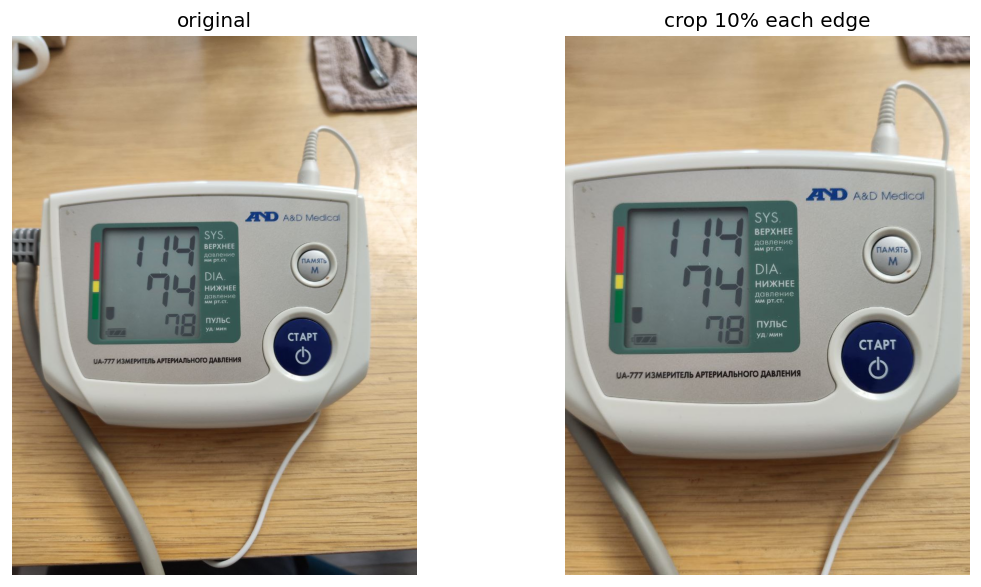

In [4]:
image_paths = collect_image_paths()
print(f"Found {len(image_paths)} images")
for path in image_paths[:5]:
    print("-", path)

if image_paths:
    sample = load_rgb(image_paths[0])
    sample_crop, sample_geometry = crop_edges(sample)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(sample)
    axes[0].set_title("original")
    axes[0].axis("off")
    axes[1].imshow(sample_crop)
    axes[1].set_title(f"crop {CROP_EDGE_RATIO:.0%} each edge")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    sample_geometry

## Load YOLOv8n

In [5]:
if importlib.util.find_spec("ultralytics") is None or importlib.util.find_spec("torch") is None:
    raise RuntimeError("Install ultralytics first: uncomment and run the %pip install cell above.")

from ultralytics import YOLO

DEVICE = choose_device()
USE_HALF = DEVICE.startswith("cuda")

model = YOLO(MODEL_NAME)
try:
    model.fuse()
except Exception:
    pass

print(f"Model: {MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"imgsz={IMG_SIZE}, conf={CONF_THRESHOLD}, iou={IOU_THRESHOLD}, half={USE_HALF}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/alex/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
Model: yolov8n.pt
Device: mps
imgsz=640, conf=0.25, iou=0.45, half=False


## Run detection

In [6]:
detections_path = OUTPUT_DIR / "detections.jsonl"
summary_csv_path = OUTPUT_DIR / "summary.csv"

all_rows: list[dict] = []
summary_rows: list[dict] = []
start_time = time.perf_counter()

with detections_path.open("w", encoding="utf-8") as f_jsonl:
    for index, image_path in enumerate(image_paths, start=1):
        img_rgb = load_rgb(image_path)
        cropped_rgb, geometry = crop_edges(img_rgb)

        crop_path = OUTPUT_DIR / "crops" / image_path.name
        annotated_crop_path = OUTPUT_DIR / "annotated_crops" / image_path.name
        annotated_original_path = OUTPUT_DIR / "annotated_originals" / image_path.name

        result = model.predict(
            cropped_rgb,
            imgsz=IMG_SIZE,
            conf=CONF_THRESHOLD,
            iou=IOU_THRESHOLD,
            device=DEVICE,
            half=USE_HALF,
            classes=CLASSES,
            verbose=False,
        )[0]

        boxes, classes, confidences = boxes_from_result(result)
        annotated_crop = draw_boxes(cropped_rgb, boxes, classes, confidences, result.names)
        annotated_original = draw_boxes(
            img_rgb,
            boxes,
            classes,
            confidences,
            result.names,
            offset=(geometry["crop_x"], geometry["crop_y"]),
        )

        save_rgb(crop_path, cropped_rgb)
        save_rgb(annotated_crop_path, annotated_crop)
        save_rgb(annotated_original_path, annotated_original)

        summary_rows.append({
            "image": str(image_path),
            "crop": str(crop_path),
            "annotated_crop": str(annotated_crop_path),
            "annotated_original": str(annotated_original_path),
            "detections": int(len(boxes)),
        })

        for det_index, (box, class_id, conf) in enumerate(zip(boxes, classes, confidences), start=1):
            x1, y1, x2, y2 = [float(v) for v in box]
            row = {
                "image": str(image_path),
                "detection_index": det_index,
                "class_id": int(class_id),
                "class_name": result.names.get(int(class_id), str(int(class_id))),
                "confidence": float(conf),
                "crop_x1": x1,
                "crop_y1": y1,
                "crop_x2": x2,
                "crop_y2": y2,
                "original_x1": x1 + geometry["crop_x"],
                "original_y1": y1 + geometry["crop_y"],
                "original_x2": x2 + geometry["crop_x"],
                "original_y2": y2 + geometry["crop_y"],
                **geometry,
            }
            all_rows.append(row)
            f_jsonl.write(json.dumps(row, ensure_ascii=False) + "\n")

        print(f"[{index:02d}/{len(image_paths):02d}] {image_path.name}: {len(boxes)} boxes")

elapsed = time.perf_counter() - start_time
print(f"Done in {elapsed:.1f}s")
print(f"Detections: {len(all_rows)}")
print(f"JSONL: {detections_path}")

[01/10] photo_2026-02-16_11-45-15.jpg: 0 boxes
[02/10] photo_2026-02-16_11-45-18.jpg: 0 boxes
[03/10] photo_2026-02-16_11-45-20.jpg: 0 boxes
[04/10] photo_2026-02-16_11-45-23.jpg: 1 boxes
[05/10] photo_2026-02-16_11-45-25.jpg: 1 boxes
[06/10] photo_2026-02-16_11-45-28.jpg: 1 boxes
[07/10] photo_2026-02-16_11-45-31.jpg: 2 boxes
[08/10] photo_2026-02-16_11-45-33.jpg: 0 boxes
[09/10] photo_2026-02-16_11-45-35.jpg: 0 boxes
[10/10] photo_2026-02-16_11-45-38.jpg: 3 boxes
Done in 1.6s
Detections: 8
JSONL: boris_fast_yolov8n_rectangles_outputs/detections.jsonl


In [7]:
with summary_csv_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["image", "crop", "annotated_crop", "annotated_original", "detections"],
    )
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"Summary: {summary_csv_path}")

Summary: boris_fast_yolov8n_rectangles_outputs/summary.csv


## Visual check

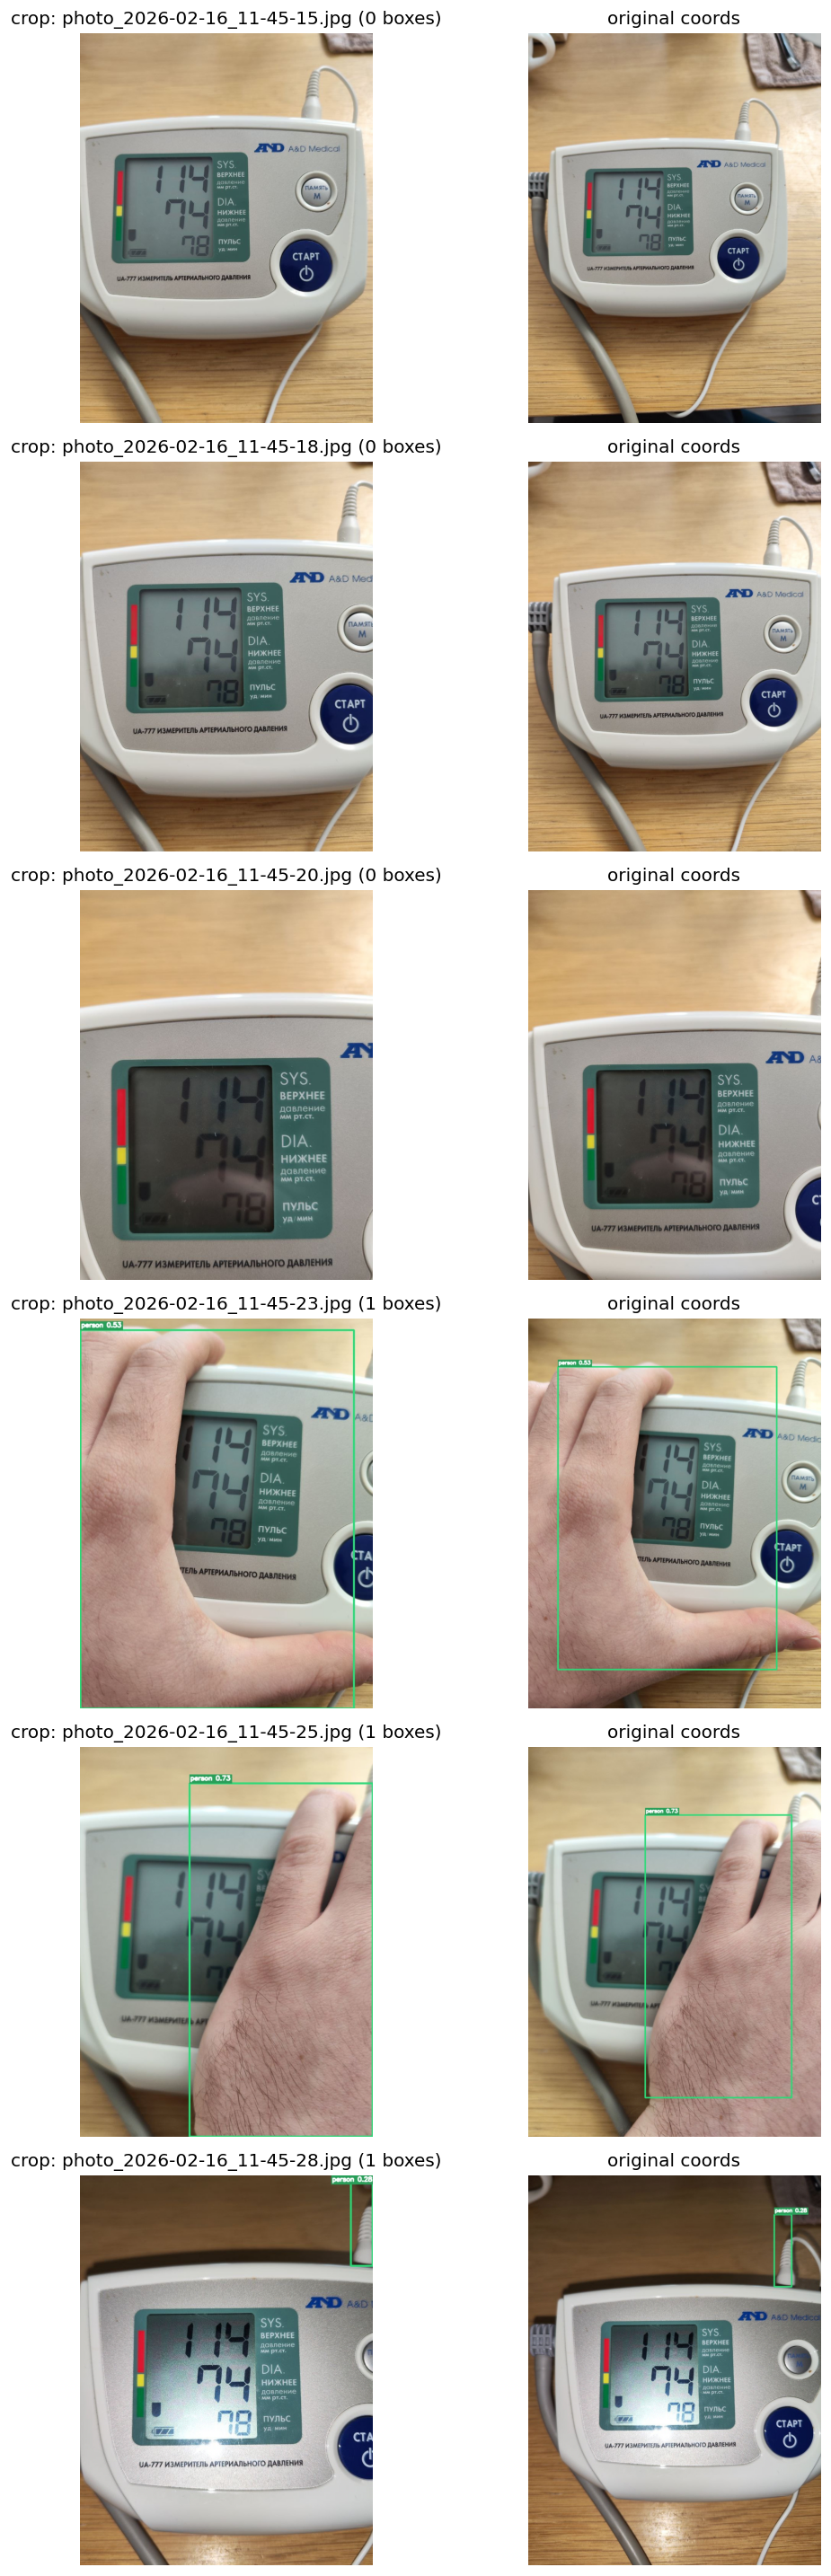

In [8]:
preview_count = min(6, len(summary_rows))
if preview_count == 0:
    print("No images to preview")
else:
    fig, axes = plt.subplots(preview_count, 2, figsize=(10, 4 * preview_count))
    if preview_count == 1:
        axes = np.array([axes])

    for ax_row, row in zip(axes, summary_rows[:preview_count]):
        crop_annotated = load_rgb(Path(row["annotated_crop"]))
        original_annotated = load_rgb(Path(row["annotated_original"]))

        ax_row[0].imshow(crop_annotated)
        ax_row[0].set_title(f"crop: {Path(row['image']).name} ({row['detections']} boxes)")
        ax_row[0].axis("off")

        ax_row[1].imshow(original_annotated)
        ax_row[1].set_title("original coords")
        ax_row[1].axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
# Быстрый просмотр таблицы детекций без pandas.
all_rows[:5]

[{'image': 'data/boris/photo_2026-02-16_11-45-23.jpg',
  'detection_index': 1,
  'class_id': 0,
  'class_name': 'person',
  'confidence': 0.5338360667228699,
  'crop_x1': 1.170068383216858,
  'crop_y1': 30.875,
  'crop_x2': 718.3558349609375,
  'crop_y2': 1024.0,
  'original_x1': 97.17006838321686,
  'original_y1': 158.875,
  'original_x2': 814.3558349609375,
  'original_y2': 1152.0,
  'crop_x': 96,
  'crop_y': 128,
  'crop_w': 768,
  'crop_h': 1024,
  'original_w': 960,
  'original_h': 1280},
 {'image': 'data/boris/photo_2026-02-16_11-45-25.jpg',
  'detection_index': 1,
  'class_id': 0,
  'class_name': 'person',
  'confidence': 0.734247088432312,
  'crop_x1': 287.6971740722656,
  'crop_y1': 95.32392883300781,
  'crop_x2': 767.4103393554688,
  'crop_y2': 1023.2950439453125,
  'original_x1': 383.6971740722656,
  'original_y1': 223.3239288330078,
  'original_x2': 863.4103393554688,
  'original_y2': 1151.2950439453125,
  'crop_x': 96,
  'crop_y': 128,
  'crop_w': 768,
  'crop_h': 1024,
  